# Options

This notebook provides a structured introduction to options and demonstrates how options strategies can be incorporated into quantitative portfolio construction, risk management, and return enhancement frameworks. We will be delving into the basics of Options, before moving on to talk about some common options strategies. The following section outlines the concepts that will be covered in this notebook.

- Option Payoffs vs Profit/Loss
- Basic Option Payoffs and Profit/Loss
- Common Option Strategies
  - Bear $Put$ Spread
  - Bull $Call$ Spread
  - Covered $Call$
  - Protective $Put$
  - Long Straddle
  - Long Strangle
  - Short Straddle
  - Short Strangle
  - Iron Condor
  - Long Butterfly Spread
  - Short Butterfly Spread
  - $Call$ Fly
  - $Put$ Fly
- Black-Scholes Option Pricing Model
- Greeks

**Note**: When we use **long** and **short** options in this notebook, we meant **buying** and **selling** the options respectively.

Import the necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 1. Option Payoffs vs Profit/Loss

In options trading, it is important to distinguish between the **payoff** of an option and its **profit or loss (P&L)**. The **payoff** refers to the value of the option at expiration and depends only on the terminal underlying price $S_t$ and the strike price $K$, without considering any cost incurred. For example, the payoff of a long call option is given by $\max(S_t - K, 0)$, while the payoff of a long put option is $\max(K - S_t, 0)$. In contrast, **profit or loss (P&L)** represents the actual financial outcome of the trade and accounts for the premium paid (or received) when entering the position. It is therefore defined as

$$
\text{P\&L} = \text{Payoff} - \text{Premium}
$$

For a long call, this becomes $\max(S_T - K, 0) - C$, where $C$ is the call premium, and for a long put, $\max(K - S_T, 0) - P$, where $P$ is the put premium. This distinction implies that while payoff diagrams always start at zero or above for long options, P&L diagrams are shifted downward by the premium, often resulting in losses unless the option finishes sufficiently in-the-money. In essence, the payoff captures the structural value of the option at expiry, whereas $P\&L$ reflects the true economic gain or loss from the trade.


### 1. Basic Option (Call  $Put$) Payoff and Profit/Loss

This section explores the basic payoff structure for buying or selling either a call or $Put$. This will lay the foundation for subsequent strategies and complex payoffs involving many options.

#### $Put$ Payoff

```put_payoff()``` is a function that calculates the payoff from buying or selling **a** $Put$. The function takes $s_t$ which is a range of possible values of the underlying price at expiration and the strike price of the $Put$ option. It then returns the $Put$ option payoff. 

Recall that:
- When the underlying price $s_t$ is less than the strike price at expiration, the $Put$ option is in the money and the payoff is the difference (i.e $\text{Strike Price} - s_t$)
- When the underlying price $s_t$ is greater than the strike price at expiration, the $Put$ option expires worthless

In [2]:
def put_payoff(sT, strike_price, action="long"): # Action can be "long" or "short", which means buying or selling the put option, respectively.
  if action == "long":
    # Buying put meaans that you will make a profit if the underlying price goes down, and you will lose money if the underlying price goes up.
    # The payoff is the difference between the strike price and the underlying price at maturity
    return np.where(sT < strike_price, strike_price - sT, 0)
  elif action == "short":
    # Selling put means that you will make a profit if the underlying price goes up, and you will lose money if the underlying price goes down.
    # The payoff is the difference between the underlying price and the strike price at maturity
    return np.where(sT < strike_price, sT - strike_price, 0)

#### $Call$ Payoff

```call_payoff()``` is a function that calculates the payoff from buying a $Call$ option. The function takes $s_t$ which is a range of possible values of the underlying price at expiration and the strike price of the $Call$ option. It returns the $Call$ option payoff.

Recall that:
- When the underlying price $s_t$ is greater than the strike price at expiration, the $Call$ option is in the money and the payoff is the difference (i.e $S_t - \text{Strike Price}$)
- When the underlying price $s_t$ is less than the strike price at expiration, the $Call$ option expires worthless

In [3]:
def call_payoff(sT, strike_price, action="long"): # Action can be "long" or "short", which means buying or selling the call option, respectively.
  if action == "long":
    # Buying call means that you will make a profit if the underlying price goes up, and you will lose money if the underlying price goes down.
    # The payoff is the difference between the underlying price and the strike price at maturity
    return np.where(sT > strike_price, sT - strike_price, 0)
  elif action == "short":
    # Selling call means that you will make a profit if the underlying price goes down, and you will lose money if the underlying price goes up.
    # The payoff is the difference between the strike price and the underlying price at maturity 
    return np.where(sT > strike_price, strike_price - sT, 0)

We will define a $\text{Profit and Loss}$ plot for the ease of visualising the final $PnL$ of the options once premium is factored into the payoffs.

In [4]:
def payoff_profit_loss_plot(sT, payoffs, premium, label_info, action, title, line_colour='g'):
  if action == "long":
    pnl = payoffs - premium
  elif action == "short":
    pnl = payoffs + premium
  fig, ax = plt.subplots(figsize=(18, 5))
  # Plot the payoff curve
  ax.plot(sT, payoffs, label=f"Payoff for {label_info}", color='grey', linestyle='-', alpha=0.3)
  # Plot the profit/loss curve
  breakeven_points = sT[np.isclose(pnl, 0, atol=0.5)]
  for be in breakeven_points: 
    ax.plot(sT, pnl, label=f"Strategy PnL | Premium = {premium:.2f} | Breakeven = {be}", color=line_colour)
  # Shade PROFIT region (green)
  ax.fill_between(sT, pnl, 0, where=(pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region')
  # Shade LOSS region (red)
  ax.fill_between(sT, pnl, 0, where=(pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region')
  # Bold the zero line
  ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
  
  plt.xlabel('XYZ Underlying Price')
  plt.ylabel('Profit / Loss')
  plt.grid()
  plt.title(title)
  plt.legend()
  plt.show()

#### $Put$ Payoff and Proft/Loss Example

Let us visualise the $Put$ Payoff and PnL diagram with the following information
- **Long** a $Put$ with $\text{Strike Price} = {\$880}$
- **Short** a $Put$ with $\text{Strike Price} = {\$860}$
- $\text{Spot Price} = {\$900}$
- Premium paid for the **Long** $Put$ is $\$15$
- Premium received for the **Short** $Put$ is $\$10$

In [5]:
spot_price = 900 

# Long Put
strike_price_long_Put = 880 
premium_long_Put = 15

# Short Put
strike_price_short_Put = 860 
premium_short_Put = 10

# underlying price range at expiration of the Put
sT = np.arange(0.9*spot_price,1.05*spot_price,1) 

**Long 880 Strike $Put$ Payoff and Profit/Loss**

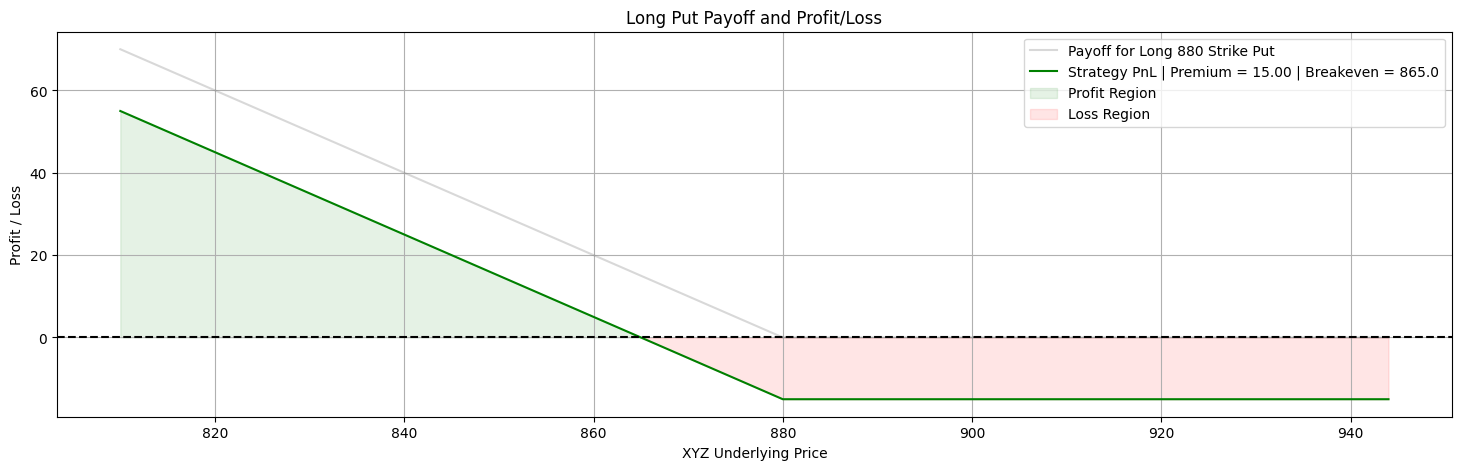

In [6]:
payoff_long_Put = put_payoff(sT, strike_price_long_Put, action="long")
payoff_profit_loss_plot(sT, payoff_long_Put, premium_long_Put, action='long', label_info='Long 880 Strike Put', title='Long Put Payoff and Profit/Loss')

**Short 860 Strike $Put$ Payoff and Profit/Loss**

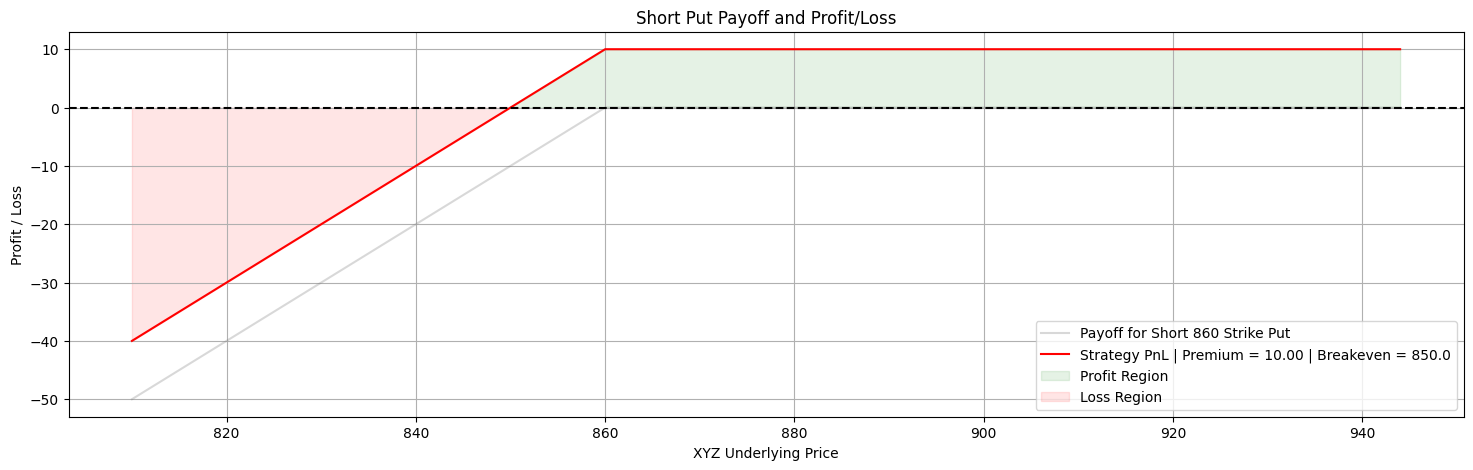

In [7]:
payoff_short_Put = put_payoff(sT, strike_price_short_Put, action="short")
payoff_profit_loss_plot(sT, payoff_short_Put, premium_short_Put, action="short", label_info="Short 860 Strike Put", title="Short Put Payoff and Profit/Loss", line_colour="r")

#### $Call$ Payoff and Proft/Loss Example

Let us visualise the Call Payoff with the following information
- **Long** a $Call$ with $\text{Strike Price} = {\$920}$
- **Short** a $Call$ with $\text{Strike Price} = {\$940}$
- $\text{Spot Price} = {\$900}$
- Premium paid for the **Long** $Call$ is $\$15$
- Premium received for the **Short** $Call$ is $\$10$

In [8]:
spot_price = 900

# Long call
strike_price_long_call = 920
premium_long_call = 15

# Short call
strike_price_short_call = 940
premium_short_call = 10

# underlying price range at expiration of the call
sT = np.arange(0.95*spot_price, 1.1*spot_price, 1)

**Long 920 Strike Call Payoff and Profit/Loss**

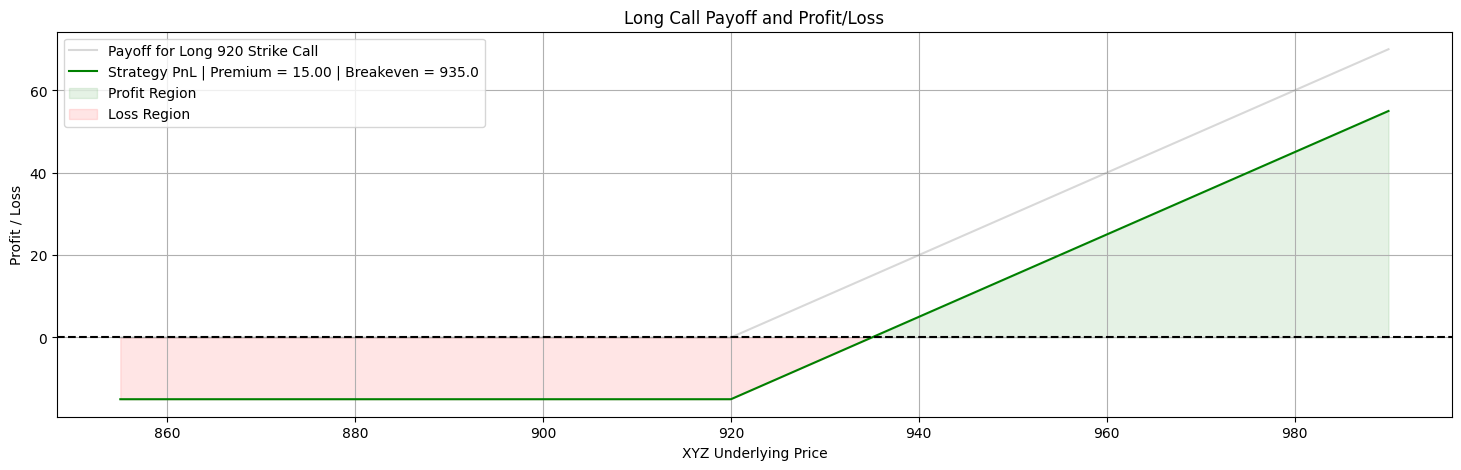

In [9]:
payoff_long_call = call_payoff(sT, strike_price_long_call, action="long")
payoff_profit_loss_plot(sT, payoff_long_call, premium_long_call, action='long', label_info='Long 920 Strike Call', title='Long Call Payoff and Profit/Loss')

**Short 940 Strike Call Payoff and Profit/Loss**

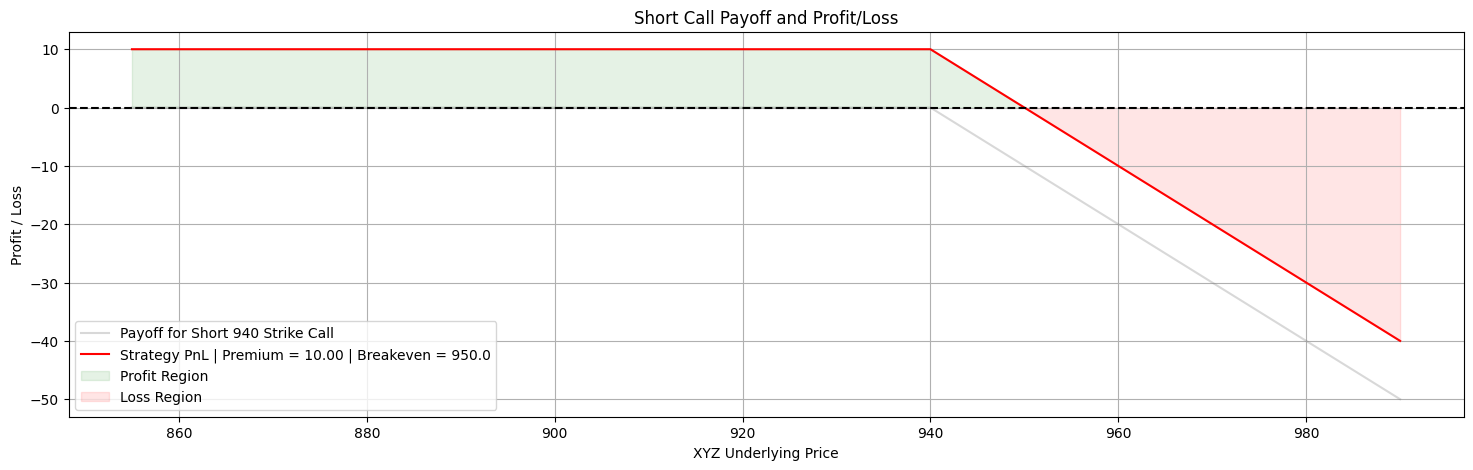

In [10]:
payoff_short_call = call_payoff(sT, strike_price_short_call, action="short")
payoff_profit_loss_plot(sT, payoff_short_call, premium_short_call, action = 'short', label_info='Short 940 Strike Call', title='Short Call Payoff and Profit/Loss', line_colour='r')

#### Combining all 4 different basic Payoff and PnL Charts

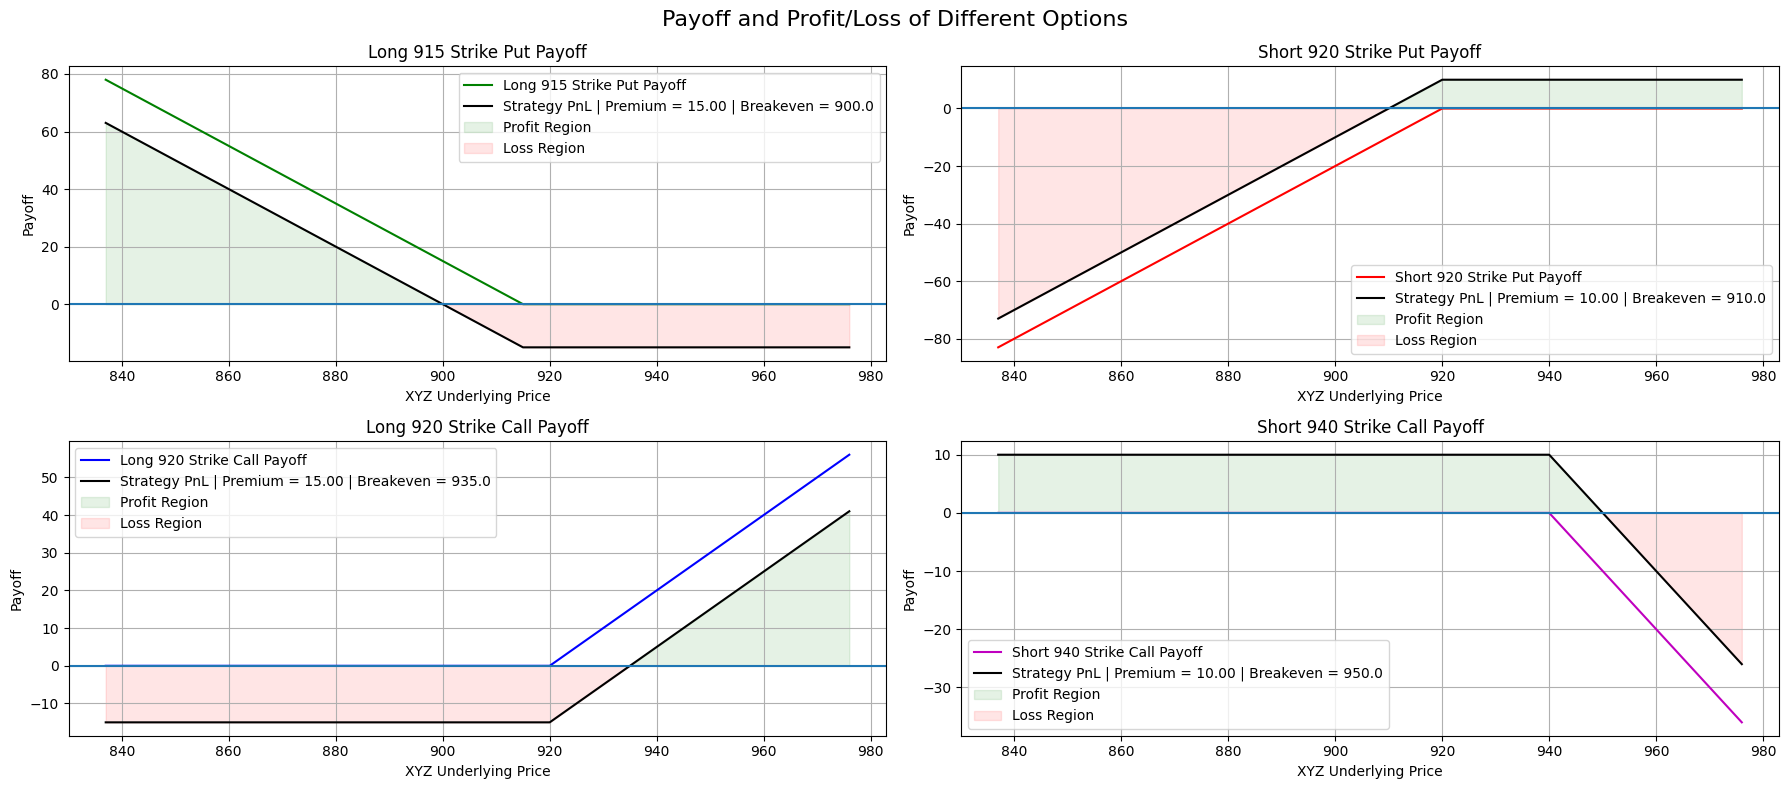

In [11]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 930
strike_price_long_Put = 915 
premium_long_Put = 15
strike_price_short_Put = 920 
premium_short_Put = 10
strike_price_long_call = 920
premium_long_call = 15
strike_price_short_call = 940
premium_short_call = 10

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.05*spot_price,1)

payoff_list = []
premium_list = [premium_long_Put, premium_short_Put, premium_long_call, premium_short_call]
payoff_list.append(put_payoff(sT, strike_price_long_Put, action="long"))
payoff_list.append(put_payoff(sT, strike_price_short_Put, action="short"))
payoff_list.append(call_payoff(sT, strike_price_long_call, action="long"))
payoff_list.append(call_payoff(sT, strike_price_short_call, action="short"))

label_list = ['Long 915 Strike Put Payoff', 'Short 920 Strike Put Payoff', 'Long 920 Strike Call Payoff', 'Short 940 Strike Call Payoff']
action = ["long", "short", "long", "short"]
colour_list = ['g', 'r', 'b', 'm']

# Plot them in 4 different quadrants with different colours and labels
fig, axs = plt.subplots(2, 2, figsize=(18, 8))
axs = axs.flatten()
for i, (payoff, premium, action, label, colour_code) in enumerate(zip(payoff_list, premium_list, action, label_list, colour_list)):
  axs[i].plot(sT, payoff, label=label, color=colour_code)
    
  # Compute PnL
  pnl = payoff - premium if action == "long" else payoff + premium

  # Plot the profit/loss curve
  breakeven_points = sT[np.isclose(pnl, 0, atol=0.5)]
  for be in breakeven_points: 
    axs[i].plot(sT, pnl, label=f"Strategy PnL | Premium = {premium:.2f} | Breakeven = {be}", color='black')
  axs[i].axhline(0)  # x-axis at zero payoff
  axs[i].fill_between(sT, pnl, 0, where=(pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region')
  axs[i].fill_between(sT, pnl, 0, where=(pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region')
  axs[i].set_title(label_list[i])
  axs[i].set_xlabel('XYZ Underlying Price')
  axs[i].set_ylabel('Payoff')
  axs[i].grid()
  axs[i].legend()
plt.suptitle('Payoff and Profit/Loss of Different Options', fontsize=16)
plt.tight_layout()
plt.show()

### 2. Common Option Strategies

#### Option Strategy 1: Bear $Put$ Spread

A Bear $Put$ Spread is a bearish options strategy that involves buying a $Put$ option at a higher $\text{Strike Price}$ and simultaneously selling another $Put$ option at a lower $\text{Strike Price}$. This structure reduces the net premium paid compared to a single long $Put$ while limiting both the maximum profit and maximum loss. The strategy benefits from a moderate decline in the underlying asset’s price before expiration. Looking at our long and short $Put$, our bear $Put$ spread payoff formula is simply:

$$
\text{Bear Put Spread (Payoff)} = \text{Long Put (Payoff)}_{\text{(Higher Strike)}} + \text{Short Put (Payoff)}_{\text{(Lower Strike)}} 
$$

Consider the following example Bear $Put$ Spread Strategy where we:
- **Long** a $Put$ with $\text{Strike Price} = {\$930}$
- **Short** a $Put$ with $\text{Strike Price} = {\$900}$
- $\text{Spot Price} = {\$930}$
- Premium paid for the **Long** $Put$ is $\$15$
- Premium received for the **Short** $Put$ is $\$10$

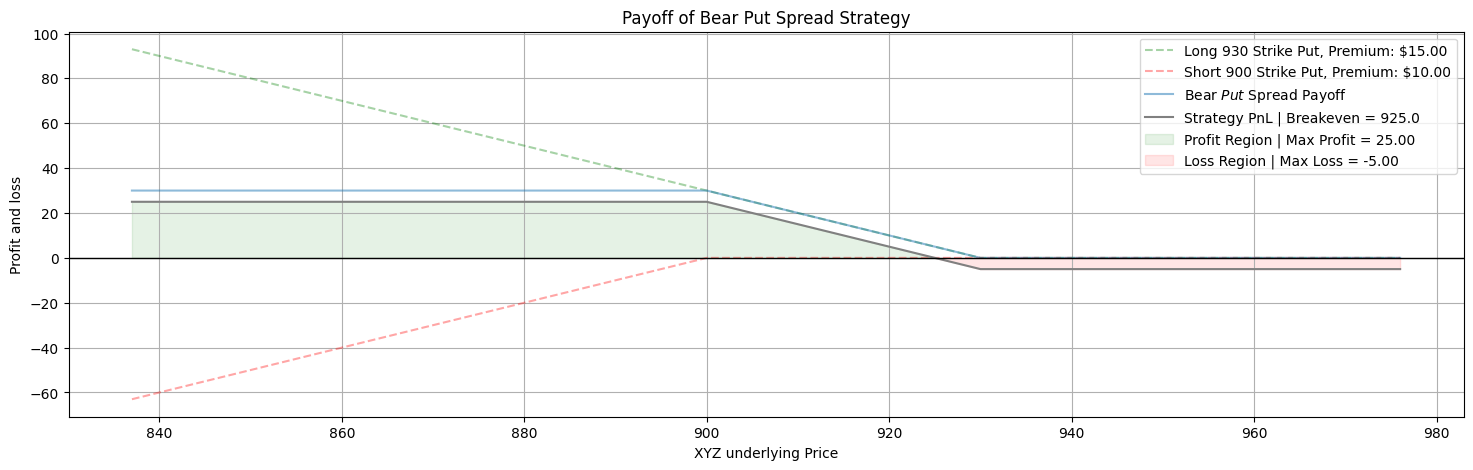

In [12]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 930
strike_price_long_Put = 930
premium_long_Put = 15
strike_price_short_Put = 900 
premium_short_Put = 10

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.05*spot_price,1)

# Individual payoff of the long and short Put
payoff_long_Put = put_payoff(sT, strike_price_long_Put, action="long")
payoff_short_Put = put_payoff(sT, strike_price_short_Put, action="short")

# Combined payoff of the long and short Put, which is the payoff of the bear Put spread strategy
payoff_bear_Put_spread = payoff_long_Put + payoff_short_Put

# Since we are long the long Put and short the short Put, we need to subtract the net premium paid (premium_long_Put - premium_short_Put)
# from the combined payoff to get the profit/loss of the bear Put spread strategy.
pnl_bear_Put_spread = payoff_bear_Put_spread - (premium_long_Put - premium_short_Put) 

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,payoff_long_Put,'--',label=f'Long 930 Strike Put, Premium: ${premium_long_Put:.2f}',color='g', alpha=0.35)
ax.plot(sT,payoff_short_Put,'--',label=f'Short 900 Strike Put, Premium: ${premium_short_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,payoff_bear_Put_spread,label='Bear $Put$ Spread Payoff', alpha=0.5)

# Plot the profit/loss curve
breakeven_points = sT[np.isclose(pnl_bear_Put_spread, 0, atol=0.5)]
for be in breakeven_points: 
  ax.plot(sT, pnl_bear_Put_spread, label=f"Strategy PnL | Breakeven = {be}", color='grey')

# Profit region
ax.fill_between(sT, pnl_bear_Put_spread, 0, where=(pnl_bear_Put_spread > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(pnl_bear_Put_spread.max()))
ax.fill_between(sT, pnl_bear_Put_spread, 0, where=(pnl_bear_Put_spread < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(pnl_bear_Put_spread.min()))

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Bear Put Spread Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

The max profit is capped at $15 and the max loss is limited to $5. Therefore, this strategy is suitable when your outlook is moderately bearish on the underlying. 

#### Option Strategy 2: Bull $Call$ Spread

A Bull $Call$ Spread is built by going long on $Call$ option and simultaneously selling a higher $\text{Strike Price}$ $Call$ option. This strategy aims to benefit from small positive movements in the underlying, and is suitable when your outlook is moderately bullish on the underlying. 

Looking at our long and short $Call$, our Bull $Call$ Spread payoff formula is simply:

$$
\text{Bull Call Spread (Payoff)} = \text{Long Call (Payoff)}_{\text{(Lower Strike)}} + \text{Short Call (Payoff)}_{\text{(Higher Strike)}} 
$$

Consider the following example Bull $Call$ Spread Strategy where we:
- **Long** a $Call$ with $\text{Strike Price} = {\$930}$
- **Short** a $Call$ with $\text{Strike Price} = {\$950}$
- $\text{Spot Price} = {\$930}$
- Premium paid for the **Long** $Call$ is $\$15$
- Premium received for the **Short** $Call$ is $\$10$

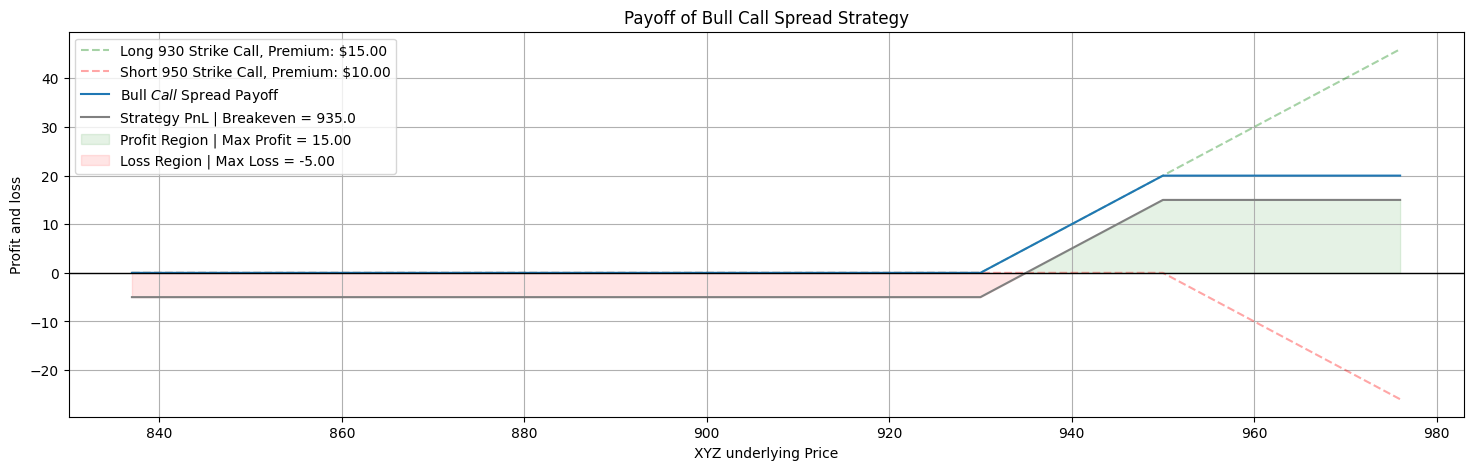

In [13]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 930
strike_price_long_Call = 930
premium_long_Call = 15
strike_price_short_Call = 950 
premium_short_Call = 10

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.05*spot_price,1)

payoff_long_Call = call_payoff(sT, strike_price_long_Call, action="long")
payoff_short_Call = call_payoff(sT, strike_price_short_Call, action="short")

# Combined payoff of the long and short Call, which is the payoff of the bull Call spread strategy
payoff_bull_call_spread = payoff_long_Call + payoff_short_Call
pnl_bull_call_spread = payoff_bull_call_spread - (premium_long_Call - premium_short_Call)

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,payoff_long_Call,'--',label=f'Long 930 Strike Call, Premium: ${premium_long_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,payoff_short_Call,'--',label=f'Short 950 Strike Call, Premium: ${premium_short_Call:.2f}',color='r', alpha=0.35)
ax.plot(sT,payoff_bull_call_spread,label='Bull $Call$ Spread Payoff')

# Plot the profit/loss curve
breakeven_points = sT[np.isclose(pnl_bull_call_spread, 0, atol=0.5)]
for be in breakeven_points: 
  ax.plot(sT, pnl_bull_call_spread, label=f"Strategy PnL | Breakeven = {be}", color='grey')
  
# Profit region
ax.fill_between(sT, pnl_bull_call_spread, 0, where=(pnl_bull_call_spread > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(pnl_bull_call_spread.max()))
ax.fill_between(sT, pnl_bull_call_spread, 0, where=(pnl_bull_call_spread < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(pnl_bull_call_spread.min()))

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Bull Call Spread Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Options Strategy 3: Covered Call

A Covered Call is an income-generating strategy that involves holding a long position in an underlying asset while simultaneously selling a $Call$ option on that same asset. The premium received from selling the $Call$ provides immediate income and offers partial downside protection. However, the upside potential is capped at the $Call$'s $\text{Strike Price}$ if the asset appreciates significantly.

$$
\text{Payoff} = 
\begin{cases} 
S_T - S_0 + C & \text{if } S_T \leq K \quad \text{(call expires worthless)} \\[1.2em]
K - S_0 + C   & \text{if } S_T > K \quad \text{(call is exercised)}
\end{cases}
$$

As for the profits and loss, they can be formulated as such:

$$
\text{Profit} = (S_T - S_0) + C - \max(S_T - K, 0)
$$

Consider the following example Covered $Call$ Strategy where we:
- **Long** the underlying at $\$930$
- **Short** a $Call$ with $\text{Strike Price} = {\$950}$
- Premium received for the **Short** $Call$ is $\$10$

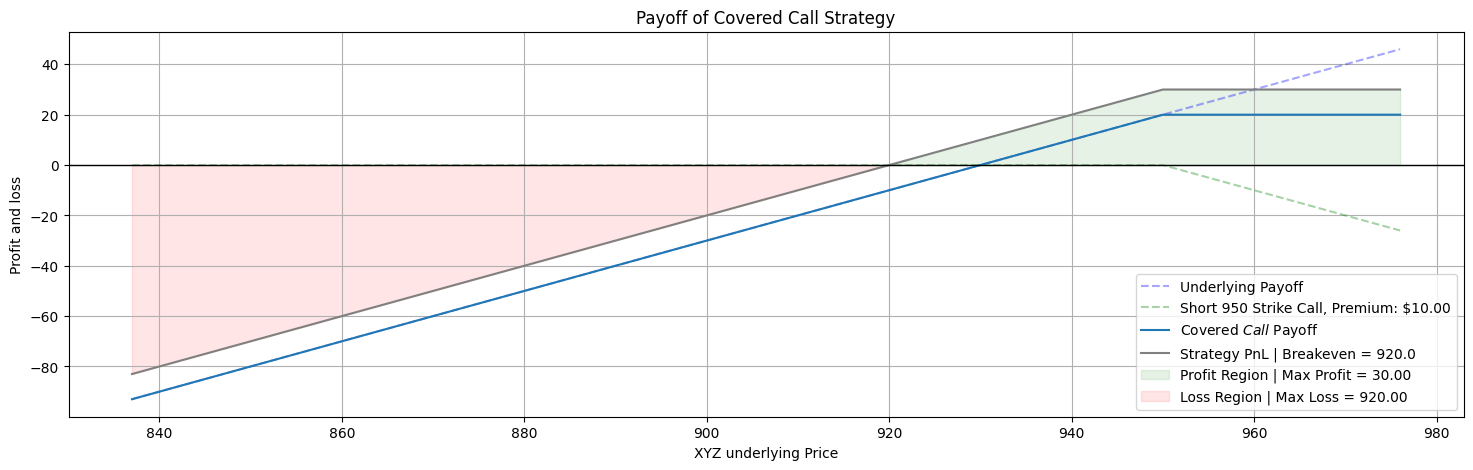

In [14]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 930
strike_price_short_Call = 950 
premium_short_Call = 10

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.05*spot_price,1)

# Buy and hold the underlying
xyz_payoff = sT - spot_price

# Short Call Option payoff
xyz_payoff_short_call = call_payoff(sT, strike_price_short_Call, action="short")

# Covered Call Option Payoff
xyz_covered_call_payoff = xyz_payoff + xyz_payoff_short_call
pnl_covered_call = xyz_covered_call_payoff + premium_short_Call  # Since we are short the call, we receive the premium, so we add it to the payoff to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff,'--',label=f'Underlying Payoff',color='b', alpha=0.35)
ax.plot(sT,xyz_payoff_short_call,'--',label=f'Short 950 Strike Call, Premium: ${premium_short_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_covered_call_payoff,label='Covered $Call$ Payoff')
  
# Plot the profit/loss curve
breakeven_points = sT[np.isclose(pnl_covered_call, 0, atol=0.5)]
for be in breakeven_points: 
  ax.plot(sT, pnl_covered_call, label=f"Strategy PnL | Breakeven = {be}", color='grey')
  
# Profit region
ax.fill_between(sT, pnl_covered_call, 0, where=(pnl_covered_call > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(pnl_covered_call.max()))
ax.fill_between(sT, pnl_covered_call, 0, where=(pnl_covered_call < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(spot_price - premium_short_Call))

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Covered Call Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 4: Protective $Put$

A Protective $Put$ is a risk-management strategy that involves holding a long position in an underlying asset while purchasing a $Put$ option on the same asset. The $Put$ acts as insurance, providing downside protection by setting a minimum exit price. While the strategy preserves unlimited upside potential, the cost of the $Put$ reduces overall returns. The strategy payoff can be expressed as follow:

$$
\text{Payoff} = 
\begin{cases} 
S_T - S_0 - P & \text{if } S_T \geq K \quad \text{(put expires worthless)} \\[1.2em]
K - S_0 - P   & \text{if } S_T < K \quad \text{(put is exercised)}
\end{cases}
$$

As for the profit and loss, it can be defined as follow:

$$
\text{Profit} = 
\begin{cases} 
S_T - S_0 - P & \text{when } S_T \geq K \\[1.2em]
K - S_0 - P   & \text{when } S_T < K
\end{cases}
$$

Consider the following example Protective $Put$ Strategy where we:
- **Long** the underlying at $\$900$
- **Long** a $Put$ with $\text{Strike Price} = {\$880}$
- Premium paid for the **Long** $Put$ is $\$15$

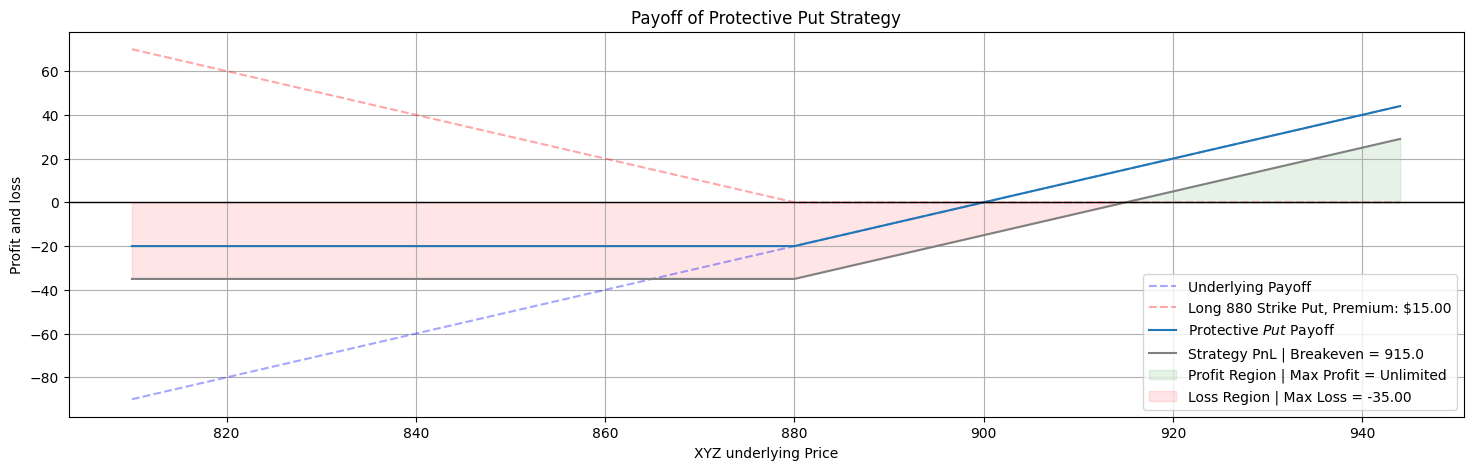

In [15]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 900
strike_price_long_Put = 880
premium_long_Put = 15

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.05*spot_price,1)

# Buy and hold the underlying
xyz_payoff = sT - spot_price

# Long Put Option payoff
xyz_payoff_long_Put = put_payoff(sT, strike_price_long_Put, action="long")

# Protective Put payoff and PnL
xyz_protective_Put_payoff = xyz_payoff + xyz_payoff_long_Put
pnl_protective_Put = xyz_protective_Put_payoff - premium_long_Put  # Since we are long the put, we need to subtract the premium paid to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff,'--',label=f'Underlying Payoff',color='b', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Put,'--',label=f'Long 880 Strike Put, Premium: ${premium_long_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_protective_Put_payoff,label='Protective $Put$ Payoff')
  
# Plot the profit/loss curve
breakeven_points = sT[np.isclose(pnl_protective_Put, 0, atol=0.5)]
for be in breakeven_points: 
  ax.plot(sT, pnl_protective_Put, label=f"Strategy PnL | Breakeven = {be}", color='grey')
  
# Profit region
ax.fill_between(sT, pnl_protective_Put, 0, where=(pnl_protective_Put > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = Unlimited')
ax.fill_between(sT, pnl_protective_Put, 0, where=(pnl_protective_Put < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(min(pnl_protective_Put)))

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Protective Put Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 5: Long Straddle

A **Long Straddle** is an options strategy that involves going Long a $Call$ and Long a $Put$ of the same underlying, with the same $\text{Strike Price}$ (usually ATM) and same expiration date  

This is a **pure volatility play**: You profit from a **large move in either direction** (up or down), but lose if the stock stays relatively flat. It is often used before expected high-volatility events (earnings, FDA decisions, macro news, etc.).

**Profit Formula at Expiration**

The profit is simply the sum of the long call profit + long put profit:

$$
\text{Profit} = \max(S_T - K, 0) - C + \max(K - S_T, 0) - P
$$

Which simplifies to:

$$
\text{Profit} = \max(S_T - K, K - S_T) - T
$$

or equivalently:

$$
\text{Profit} = |S_T - K| - (C + P)
$$

- You make money when the absolute move $|S_T - K|$ > total premium paid.
- Maximum loss occurs when $S_T = K$ (both options expire worthless).

Consider the following example Long Straddle Strategy where we:
- **Long** a $Call$ with $\text{Strike Price} = {\$880}$
- **Long** a $Put$ with $\text{Strike Price} = {\$880}$
- Premium paid for the **Long** $Call$ is $\$15$
- Premium paid for the **Long** $Put$ is $\$10$

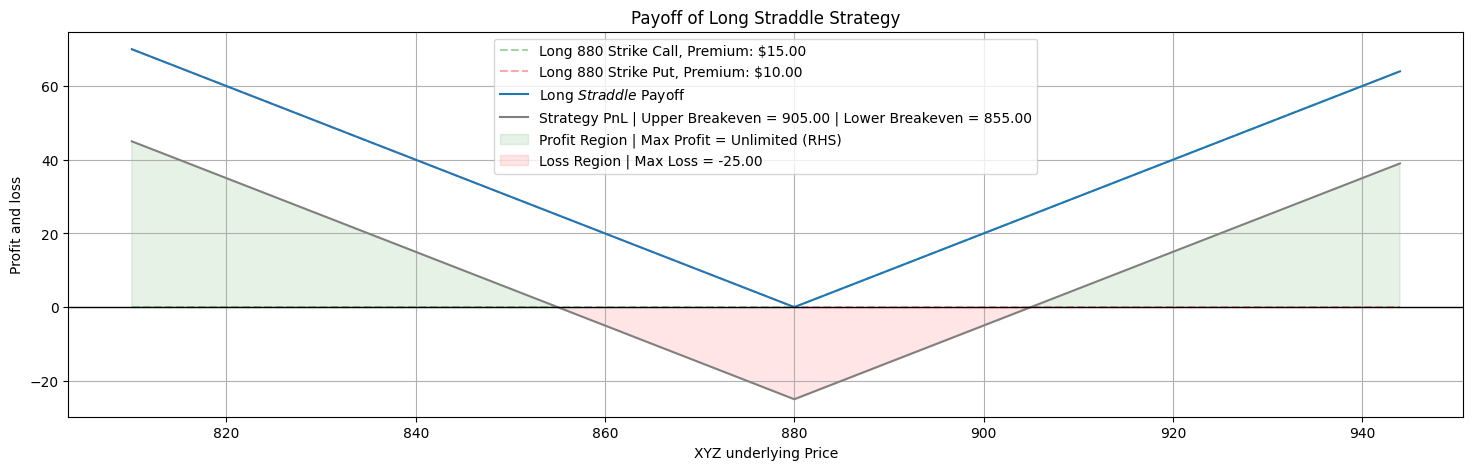

In [23]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 900
strike_price_long_Call = 880
premium_long_Call = 15
strike_price_long_Put = 880
premium_long_Put = 10

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.05*spot_price,1)

# Long Put Option payoff
xyz_payoff_long_Put = put_payoff(sT, strike_price_long_Put, action="long")
xyz_payoff_long_Call = call_payoff(sT, strike_price_long_Call, action="long")

# Long Straddle payoff and PnL
xyz_long_Straddle_payoff = xyz_payoff_long_Call + xyz_payoff_long_Put
xyz_long_Straddle_pnl = xyz_long_Straddle_payoff - (premium_long_Call + premium_long_Put)  # Since we are long both the call and the put, we need to subtract the total premium paid to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_long_Call,'--',label=f'Long 880 Strike Call, Premium: ${premium_long_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Put,'--',label=f'Long 880 Strike Put, Premium: ${premium_long_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_long_Straddle_payoff,label='Long $Straddle$ Payoff')
  
# Plot the profit/loss curve
lower_be = strike_price_long_Put  - (premium_long_Call + premium_long_Put)
upper_be = strike_price_long_Call + (premium_long_Call + premium_long_Put)
ax.plot(sT, xyz_long_Straddle_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
  
# Profit region
ax.fill_between(sT, xyz_long_Straddle_pnl, 0, where=(xyz_long_Straddle_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = Unlimited (RHS)')
ax.fill_between(sT, xyz_long_Straddle_pnl, 0, where=(xyz_long_Straddle_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(min(xyz_long_Straddle_pnl)))

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Long Straddle Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 6: Long Strangle

A **Long Strangle** strategy involves going Long on 1 OTM $Call$ and Long 1 OTM $Put$ of the same underlying, with the same expiration date. The only difference lie in the $\text{Strike Price}$, where the $\text{Strike Price}$ of the $Call$ $>$ $\text{Strike Price}$ of the $Put$, (usually equidistant from current price, both out-of-the-money)

This is a **volatility / big-move play**, similar to a long straddle but **cheaper** (because OTM options cost less) and requiring a **larger price move** to profit. It is used when you expect significant volatility but want lower upfront cost than a straddle.

**Payoff / Profit Formula at Expiration**

Profit = long call payoff + long put payoff net of premium paid:

$$
\text{Profit} = \max(S_T - K_c, 0) - C + \max(K_p - S_T, 0) - P
$$

Which simplifies to:

$$
\text{Profit} = 
\begin{cases} 
S_T - K_c - T & \text{if } S_T > K_c \quad \text{(call ITM, put worthless)} \\[1.2em]
K_p - S_T - T & \text{if } S_T < K_p \quad \text{(put ITM, call worthless)} \\[1.2em]
-T               & \text{if } K_p \leq S_T \leq K_c \quad \text{(both expire worthless)}
\end{cases}
$$

Compact version:

$$
\text{Profit} = \max(S_T - K_c, K_p - S_T, 0) - T
$$

- Maximum loss = total premium paid ($-T$), occurs anywhere between the two strikes (including at $S_0$)
- Breakevens: $K_p - T$ (lower) and $K_c + T$ (upper)

Consider the following example Long Strangle Strategy where we:
- **Long** a $Call$ with $\text{Strike Price} = {\$110}$
- **Long** a $Put$ with $\text{Strike Price} = {\$90}$
- $\text{Spot Price} = {\$100}$
- Premium paid for the **Long** $Call$ is $\$2.50$
- Premium paid for the **Long** $Put$ is $\$2.00$

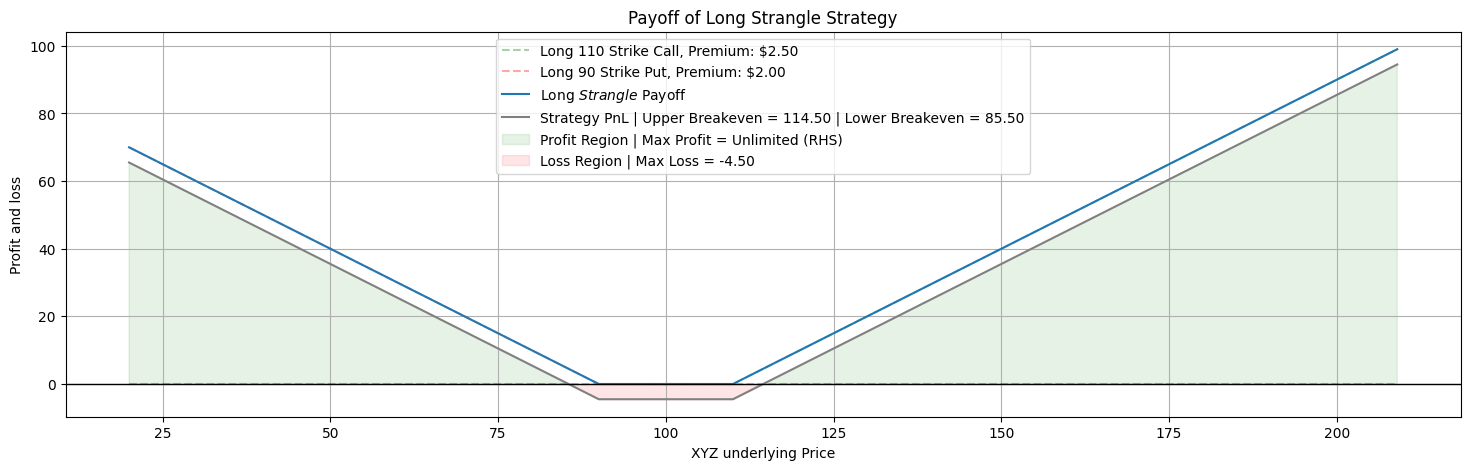

In [22]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 100
strike_price_long_Call = 110
premium_long_Call = 2.50
strike_price_long_Put = 90
premium_long_Put = 2.00

# underlying price range at expiration of the Option
sT = np.arange(0.2*spot_price,2.1*spot_price,1)

# Long Put and Call Option payoff
xyz_payoff_long_Put = put_payoff(sT, strike_price_long_Put, action="long")
xyz_payoff_long_Call = call_payoff(sT, strike_price_long_Call, action="long")

# Long Strangle payoff and PnL
xyz_long_Strangle_payoff = xyz_payoff_long_Call + xyz_payoff_long_Put
xyz_long_Strangle_pnl = xyz_long_Strangle_payoff - (premium_long_Call + premium_long_Put)  # Since we are long both the call and the put, we need to subtract the total premium paid to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_long_Call,'--',label=f'Long 110 Strike Call, Premium: ${premium_long_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Put,'--',label=f'Long 90 Strike Put, Premium: ${premium_long_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_long_Strangle_payoff,label='Long $Strangle$ Payoff')
  
# Plot the profit/loss curve
lower_be = strike_price_long_Put  - (premium_long_Call + premium_long_Put)
upper_be = strike_price_long_Call + (premium_long_Call + premium_long_Put)
  
# Profit region
ax.plot(sT, xyz_long_Strangle_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
ax.fill_between(sT, xyz_long_Strangle_pnl, 0, where=(xyz_long_Strangle_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = Unlimited (RHS)')
ax.fill_between(sT, xyz_long_Strangle_pnl, 0, where=(xyz_long_Strangle_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(min(xyz_long_Strangle_pnl)))

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Long Strangle Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 7: Short Straddle

A **Short Straddle** options strategy involves going **Short** 1 $Call$ and **Short** 1 $Put$ of the same underlying, with the same strike price (usually ATM) and same expiration date.

This is the **opposite** of a long straddle: a **short volatility** play. You collect premium upfront and profit if the stock price stays relatively flat (within a range) until expiration. Maximum profit = total premium received. Risk is theoretically **unlimited** on both sides if the stock makes a large move.

**Payoff / Profit Formula at Expiration**

Profit = short call profit + short put profit:

$$
\text{Profit} = - \max(S_T - K, 0) + C - \max(K - S_T, 0) + P
$$

Which simplifies to:

$$
\text{Profit} = T - \max(S_T - K, K - S_T)
$$

or equivalently:

$$
\text{Profit} = (C + P) - |S_T - K|
$$

- Maximum profit = total premium received ($T$), occurs when $S_T = K$ (both options expire worthless)
- You lose money when $|S_T - K| > T$
- Breakevens: $K - T$ (lower) and $K + T$ (upper)

Consider the following example Short Straddle Strategy where we:
- **Short** a $Call$ with $\text{Strike Price} = {\$100}$
- **Short** a $Put$ with $\text{Strike Price} = {\$100}$
- $\text{Spot Price} = {\$100}$
- Premium received for the **Short** $Call$ is $\$4.20$
- Premium received for the **Short** $Put$ is $\$3.80$


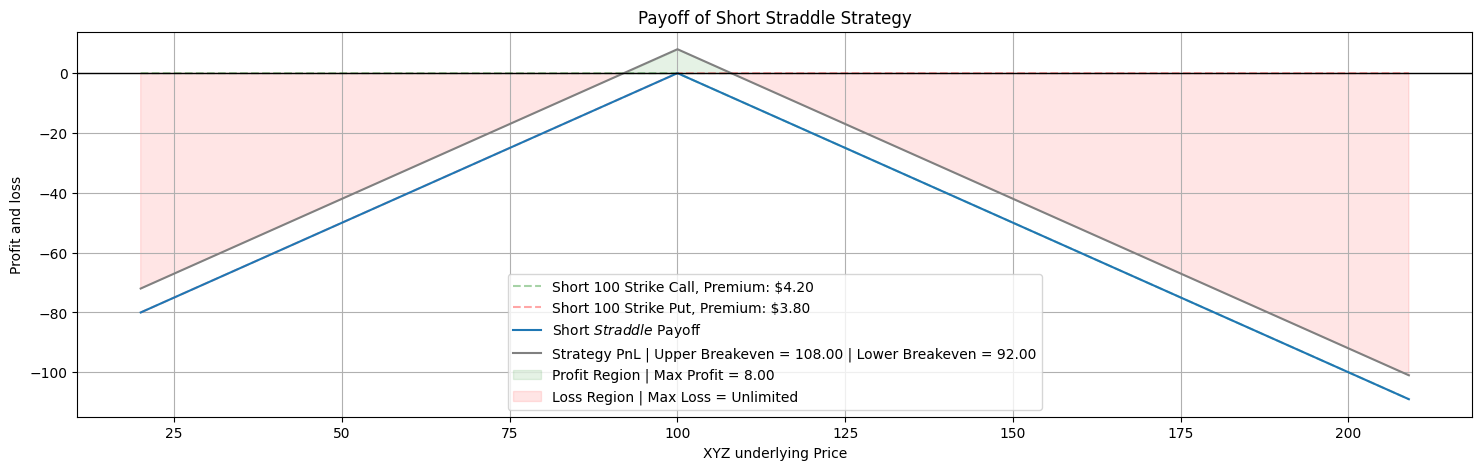

In [26]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 100
strike_price_short_Call = 100
premium_short_Call = 4.20
strike_price_short_Put = 100
premium_short_Put = 3.80

# underlying price range at expiration of the Option
sT = np.arange(0.2*spot_price,2.1*spot_price,1)

# Short Put and Call Option payoff
xyz_payoff_short_Put = put_payoff(sT, strike_price_short_Put, action="short")
xyz_payoff_short_Call = call_payoff(sT, strike_price_short_Call, action="short")

# Short Straddle payoff and PnL
xyz_short_Straddle_payoff = xyz_payoff_short_Call + xyz_payoff_short_Put
xyz_short_Straddle_pnl = xyz_short_Straddle_payoff + (premium_short_Call + premium_short_Put)  # Since we are short both the call and the put, we receive the total premium and add then to the PnL

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_short_Call,'--',label=f'Short 100 Strike Call, Premium: ${premium_short_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_short_Put,'--',label=f'Short 100 Strike Put, Premium: ${premium_short_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_short_Straddle_payoff,label='Short $Straddle$ Payoff')
  
# Plot the profit/loss curve
lower_be = strike_price_short_Put  - (premium_short_Call + premium_short_Put)
upper_be = strike_price_short_Call + (premium_short_Call + premium_short_Put)
  
# Profit region
ax.plot(sT, xyz_short_Straddle_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
ax.fill_between(sT, xyz_short_Straddle_pnl, 0, where=(xyz_short_Straddle_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(premium_short_Call + premium_short_Put) )
ax.fill_between(sT, xyz_short_Straddle_pnl, 0, where=(xyz_short_Straddle_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = Unlimited')

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Short Straddle Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 8: Short Strangle

A **Short Strangle** is an options strategy that involves going **Short** one OTM $Call$ and going **Short** one OTM $Put$, of the same underlying with the same expiration date.

The only difference is that the $\text{Strike Price}$ of the $Call$ $>$ $\text{Current Price}$ $>$ $\text{Strike Price}$ of the $Put$ (both out-of-the-money)

This is a **short volatility** strategy, similar to a short straddle but with **wider profit zone** and **lower premium collected**. You profit if the stock price stays **between the two strikes** (or even a bit beyond, thanks to the credit received). Maximum profit = total premium received. Risk is **unlimited** on the upside and **substantial** on the downside.

**Payoff / Profit Formula at Expiration**

Profit = short call profit + short put profit:

$$
\text{Profit} = -\max(S_T - K_c, 0) + C - \max(K_p - S_T, 0) + P
$$

Which simplifies to:

$$
\text{Profit} = 
\begin{cases} 
T - (S_T - K_c) & \text{if } S_T > K_c \quad \text{(short call in-the-money)} \\[1.2em]
T - (K_p - S_T) & \text{if } S_T < K_p \quad \text{(short put in-the-money)} \\[1.2em]
T               & \text{if } K_p \leq S_T \leq K_c \quad \text{(both options expire worthless)}
\end{cases}
$$

or compactly:

$$
\text{Profit} = T - \max(S_T - K_c, K_p - S_T, 0)
$$

- Maximum profit = total credit received ($T$), achieved anywhere between $K_p$ and $K_c$
- Breakevens: $K_p - T$ (lower) and $K_c + T$ (upper)

Consider the following example Short Strangle Strategy where we:
- **Short** a $Call$ with $\text{Strike Price} = {\$110}$
- **Short** a $Put$ with $\text{Strike Price} = {\$90}$
- $\text{Spot Price} = {\$100}$
- Premium received for the **Short** $Call$ is $\$2.50$
- Premium received for the **Short** $Put$ is $\$2.00$

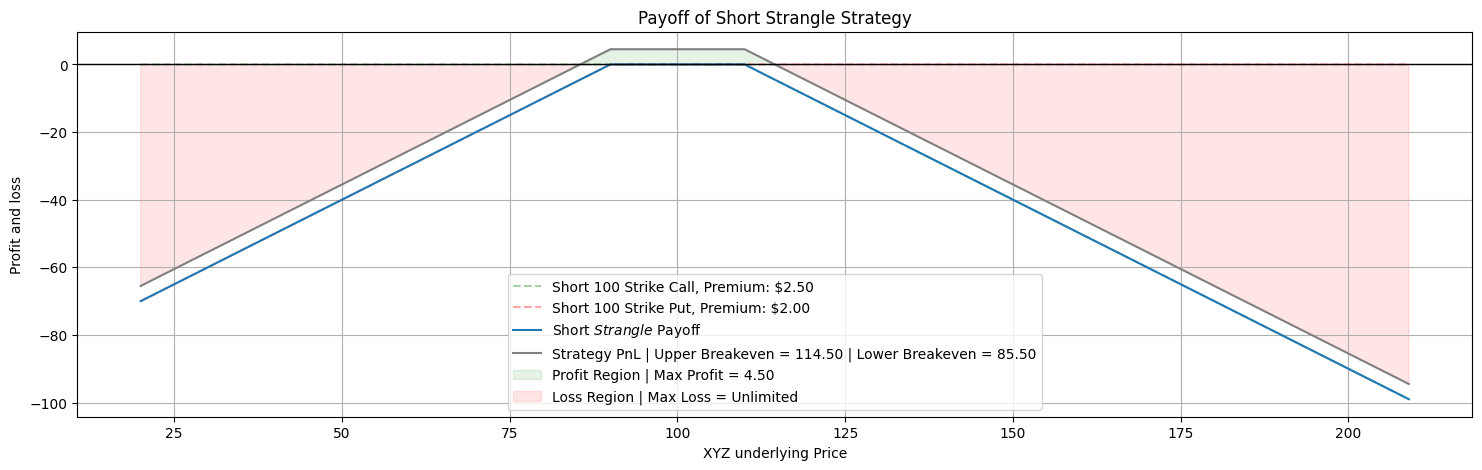

In [28]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 100
strike_price_short_Call = 110
premium_short_Call = 2.50
strike_price_short_Put = 90
premium_short_Put = 2.00

# underlying price range at expiration of the Option
sT = np.arange(0.2*spot_price,2.1*spot_price,1)

# Short Put and Call Option payoff
xyz_payoff_short_Put = put_payoff(sT, strike_price_short_Put, action="short")
xyz_payoff_short_Call = call_payoff(sT, strike_price_short_Call, action="short")

# Short Strangle payoff and PnL
xyz_short_Strangle_payoff = xyz_payoff_short_Call + xyz_payoff_short_Put
xyz_short_Strangle_pnl = xyz_short_Strangle_payoff + (premium_short_Call + premium_short_Put)  # Since we are short both the call and the put, we receive the total premium and add then to the PnL

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_short_Call,'--',label=f'Short 100 Strike Call, Premium: ${premium_short_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_short_Put,'--',label=f'Short 100 Strike Put, Premium: ${premium_short_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_short_Strangle_payoff,label='Short $Strangle$ Payoff')
  
# Plot the profit/loss curve
lower_be = strike_price_short_Put  - (premium_short_Call + premium_short_Put)
upper_be = strike_price_short_Call + (premium_short_Call + premium_short_Put)
  
# Profit region
ax.plot(sT, xyz_short_Strangle_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
ax.fill_between(sT, xyz_short_Strangle_pnl, 0, where=(xyz_short_Strangle_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(premium_short_Call + premium_short_Put) )
ax.fill_between(sT, xyz_short_Strangle_pnl, 0, where=(xyz_short_Strangle_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = Unlimited')

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Short Strangle Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 9: Iron Condor

A **Short Iron Condor** (classic credit version) is an options strategy where we  
- Sell 1 OTM $Put$ (Short $Put$)  
- Buy 1 further OTM $Put$ (Long $Put$ — protection)  
- Sell 1 OTM $Call$ (Short $Call$)  
- Buy 1 further OTM $Call$ (Long $Call$ — protection)  

All four legs have the **same expiration**, and this is a combination of a **bull put credit spread** + **bear call credit spread**. This is a **short volatility**, **range-bound** strategy: you collect net premium upfront and profit if the underlying stays **inside a wide range** until expiration. Risk is **defined** (unlike naked strangle/straddle).

Given the following parameters:
- $S_0$ = current underlying price
- $S_T$ = price at expiration
- $K_{p1}$ = long put strike (lowest, protection)
- $K_{p2}$ = short put strike ($K_{p1} < K_{p2} < S_0$)
- $K_{c1}$ = short call strike ($S_0 < K_{c1} < K_{c2}$)
- $K_{c2}$ = long call strike (highest, protection)
- Put spread width = $K_{p2} - K_{p1}$  
- Call spread width = $K_{c2} - K_{c1}$  
- Usually symmetric: put width = call width  
- Net credit received = $T$ = (short put premium + short call premium) − (long put premium + long call premium)

**Payoff / Profit Formula at Expiration**

$$
\text{Profit} = T - \left[ \max(K_{p2} - S_T, 0) - \max(K_{p1} - S_T, 0) \right] - \left[ \max(S_T - K_{c1}, 0) - \max(S_T - K_{c2}, 0) \right]
$$

Piecewise (most useful form):

$$
\text{Profit} = 
\begin{cases} 
T - (K_{p2} - K_{p1}) & \text{if } S_T < K_{p1} \quad \text{(max loss — put side)} \\[1.2em]
T + (S_T - K_{p2}) & \text{if } K_{p1} < S_T < K_{p2} \\[1.2em]
T & \text{if } K_{p2} \leq S_T \leq K_{c1} \quad \text{(max profit zone)} \\[1.2em]
T - (S_T - K_{c1}) & \text{if } K_{c1} < S_T < K_{c2} \\[1.2em]
T - (K_{c2} - K_{c1}) & \text{if } S_T > K_{c2} \quad \text{(max loss — call side)}
\end{cases}
$$

- Max profit = net credit $T$ (both spreads expire worthless)
- Max loss = spread width − $T$ (assuming symmetric wings; uses the wider wing if asymmetric)
- Breakevens: Lower = $K_{p2} - T$ ; Upper = $K_{c1} + T$

Consider the following example Iron Condor Strategy where we:
- **Long** a $Put$ with $\text{Strike Price} = {\$90}$
- **Short** a $Put$ with $\text{Strike Price} = {\$95}$
- **Long** a $Call$ with $\text{Strike Price} = {\$105}$
- **Short** a $Call$ with $\text{Strike Price} = {\$110}$
- $\text{Spot Price} = {\$100}$
- Premium received for the **Short** $Call$ is $\$2.30$
- Premium received for the **Short** $Put$ is $\$2.10$
- Premium paid for the **Long** $Call$ is $\$0.90$
- Premium paid for the **Long** $Put$ is $\$0.80$

Quick Calculations before moving forward:

→ Put credit = 2.10 − 0.80 = $1.30  
→ Call credit = 2.30 − 0.90 = $1.40  
→ Net credit $T = 2.70$ (per share, ×100 = $270 credit)


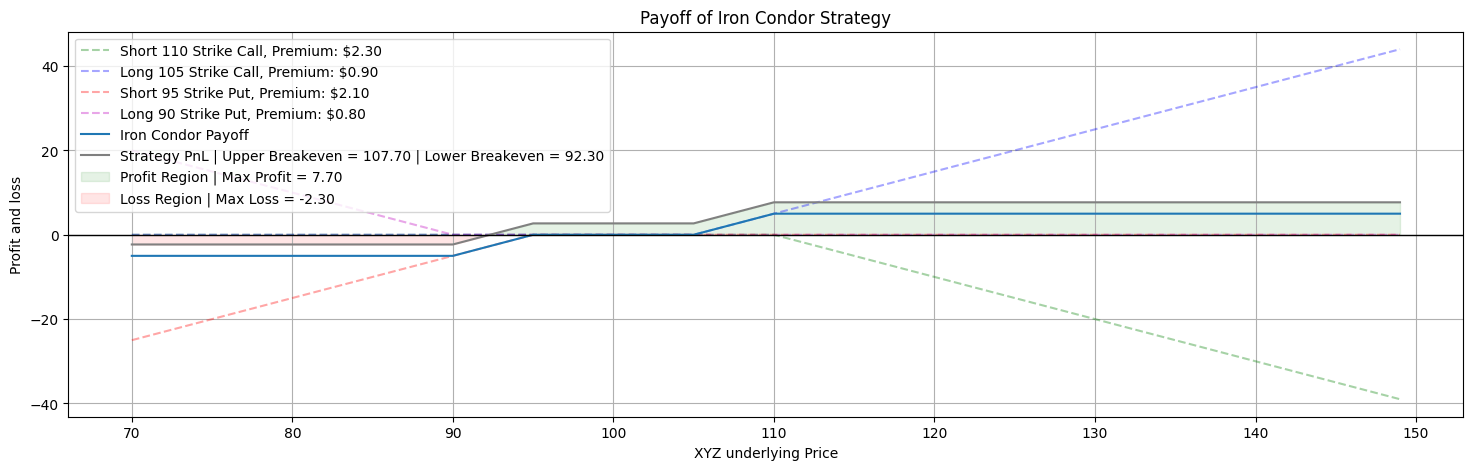

In [37]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 100
strike_price_long_Put = 90
premium_long_Put = 0.80
strike_price_short_Put = 95
premium_short_Put = 2.10

strike_price_long_Call = 105
premium_long_Call = 0.90
strike_price_short_Call = 110
premium_short_Call = 2.30

# underlying price range at expiration of the Option
sT = np.arange(0.7*spot_price,1.5*spot_price,1)

# Payoff of the 4 individual options
xyz_payoff_long_Put = put_payoff(sT, strike_price_long_Put, action="long")
xyz_payoff_short_Put = put_payoff(sT, strike_price_short_Put, action="short")
xyz_payoff_long_Call = call_payoff(sT, strike_price_long_Call, action="long")
xyz_payoff_short_Call = call_payoff(sT, strike_price_short_Call, action="short")

# Iron Condor payoff and PnL
xyz_Iron_Condor_payoff = xyz_payoff_long_Call + xyz_payoff_short_Call + xyz_payoff_long_Put + xyz_payoff_short_Put
net_premium = (premium_short_Call + premium_short_Put) - (premium_long_Call + premium_long_Put)  # We receive the premium from the short call and put, and we pay the premium for the long call and put, so we subtract the total premium paid from the total premium received to get the net premium.
xyz_Iron_Condor_pnl = xyz_Iron_Condor_payoff + net_premium  # Since we receive the net premium, we add it to the payoff to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_short_Call,'--',label=f'Short 110 Strike Call, Premium: ${premium_short_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Call,'--',label=f'Long 105 Strike Call, Premium: ${premium_long_Call:.2f}',color='b', alpha=0.35)
ax.plot(sT,xyz_payoff_short_Put,'--',label=f'Short 95 Strike Put, Premium: ${premium_short_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Put,'--',label=f'Long 90 Strike Put, Premium: ${premium_long_Put:.2f}',color='m', alpha=0.35)
ax.plot(sT,xyz_Iron_Condor_payoff,label='Iron Condor Payoff')
  
lower_be = strike_price_short_Put  - net_premium
upper_be = strike_price_long_Call + net_premium
  
# Profit region
ax.plot(sT, xyz_Iron_Condor_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
ax.fill_between(sT, xyz_Iron_Condor_pnl, 0, where=(xyz_Iron_Condor_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(max(xyz_Iron_Condor_pnl)) )
ax.fill_between(sT, xyz_Iron_Condor_pnl, 0, where=(xyz_Iron_Condor_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(min(xyz_Iron_Condor_pnl)) )

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Iron Condor Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 10: Long Butterfly Spread

A **Long Butterfly Spread** (classic debit version) is an options strategy that uses **four options** at **three equidistant strikes**:  
- Buy 1 lower-strike option (wing)  
- Sell 2 middle-strike options (body)  
- Buy 1 higher-strike option (wing)  

All same expiration, same type (all $Calls$ **or** all $Puts$). It is a **market-neutral, low-volatility** strategy: you pay a small debit upfront and profit maximally if the underlying **pins exactly** (or very close) to the middle strike at expiration.

Given the following key Parameters
- $S_0$ = current underlying price
- $S_T$ = price at expiration
- $K_l$ = lower strike (long wing, usually ITM or near ATM)
- $K_m$ = middle strike (short 2 options, usually ATM or target pin)
- $K_h$ = higher strike (long wing)
- Wing width = $d = K_m - K_l = K_h - K_m$ (symmetric)
- Net debit paid = $D$ (total cost of longs minus credit from 2 shorts)

**Payoff / Profit Formula at Expiration**

$$
\text{Profit} = \max(S_T - K_l, 0) - 2 \cdot \max(S_T - K_m, 0) + \max(S_T - K_h, 0) - D \quad \text{(call version)}
$$

or equivalently (piecewise):

$$
\text{Profit} = 
\begin{cases} 
0 - D & \text{if } S_T \leq K_l \quad \text{(all expire worthless or net zero)} \\[1.2em]
(S_T - K_l) - D & \text{if } K_l < S_T < K_m \\[1.2em]
(S_T - K_l) - 2(S_T - K_m) - D = (2K_m - K_l - S_T) - D & \text{if } K_m \leq S_T \leq K_h \\[1.2em]
(S_T - K_l) - 2(S_T - K_m) + (S_T - K_h) - D = 0 - D & \text{if } S_T \geq K_h
\end{cases}
$$

- Max profit = $d - D$ → occurs **exactly** at $S_T = K_m$
- Max loss = $D$ (net debit paid) → occurs if $S_T \leq K_l$ or $S_T \geq K_h$
- Breakevens: Lower = $K_l + D$ ; Upper = $K_h - D$

(For **put butterfly**, the formula mirrors but uses put payoffs; payoff shape is identical.)

Consider the following example Iron Condor Strategy where we:
- **Long** a $Call$ with $\text{Strike Price} = {\$95}$
- **Short** two $Calls$ with $\text{Strike Price} = {\$100}$
- **Long** a $Call$ with $\text{Strike Price} = {\$105}$
- $\text{Spot Price} = {\$100}$
- Premium received for the **Short** $Call$ is $\$3.10$ each
- Premium paid for the **Long** $Call$ with $\text{Strike Price} = {\$95}$ is $\$7.00$
- Premium paid for the **Long** $Call$ with $\text{Strike Price} = {\$105}$ is $\$1.20$

Quick Calculations before moving forward:

→ Net debit $D = (7.00 + 1.20) - 6.20 = \$2.00$  
→ Wing width $d = 5$ → Max profit = $5 - 2 = \$3.00$ ($300 per contract)

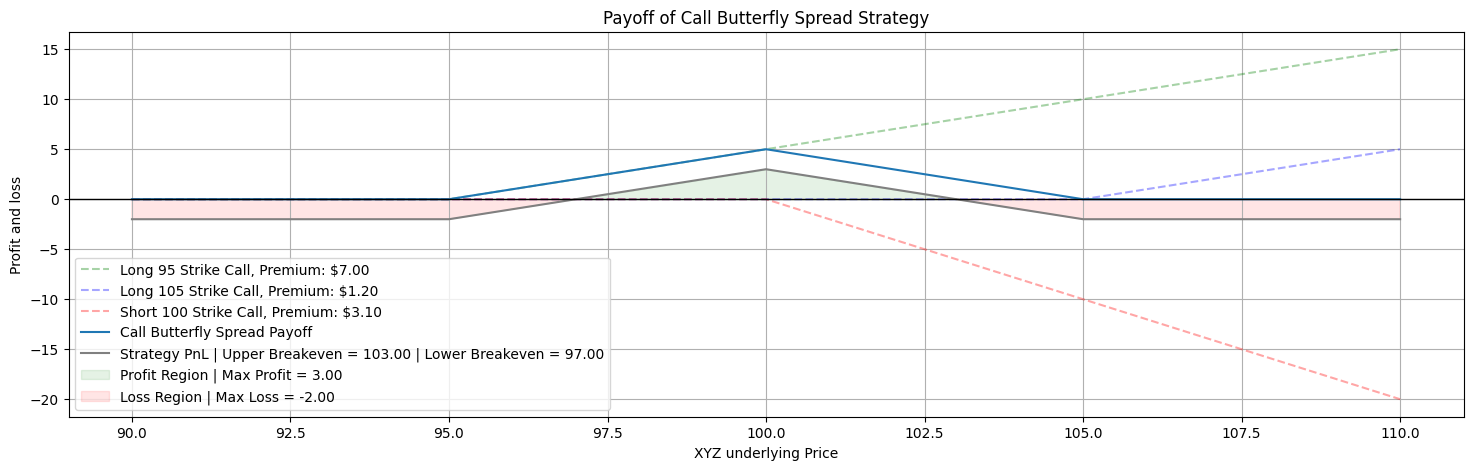

In [42]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 100
strike_price_long_Call_1 = 95
premium_long_Call_1 = 7.00
strike_price_long_Call_2 = 105
premium_long_Call_2 = 1.20
strike_price_short_Call = 100
premium_short_Call = 3.10

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.1*spot_price,1)

# Payoff of the 3 individual options
xyz_payoff_long_Call_1 = call_payoff(sT, strike_price_long_Call_1, action="long")
xyz_payoff_long_Call_2 = call_payoff(sT, strike_price_long_Call_2, action="long")
xyz_payoff_short_Call = 2 * call_payoff(sT, strike_price_short_Call, action="short") # Multiply by 2 since we are short 2 call options at the same strike price.

# Call Butterfly Spread payoff and PnL
xyz_Call_Butterfly_payoff = xyz_payoff_long_Call_1 + xyz_payoff_long_Call_2 + xyz_payoff_short_Call
net_premium = premium_long_Call_1 + premium_long_Call_2 - 2 * premium_short_Call  # We pay the premium for the 2 long calls and receive the premium for the short call, so we subtract the total premium paid from the total premium received to get the net premium.
xyz_Call_Butterfly_pnl = xyz_Call_Butterfly_payoff - net_premium  # Since we pay the net premium, we subtract it from the payoff to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_long_Call_1,'--',label=f'Long 95 Strike Call, Premium: ${premium_long_Call_1:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Call_2,'--',label=f'Long 105 Strike Call, Premium: ${premium_long_Call_2:.2f}',color='b', alpha=0.35)
ax.plot(sT,xyz_payoff_short_Call,'--',label=f'Short 100 Strike Call, Premium: ${premium_short_Call:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_Call_Butterfly_payoff,label='Call Butterfly Spread Payoff')

# Breakeven points
lower_be = strike_price_long_Call_1 + net_premium
upper_be = strike_price_long_Call_2 - net_premium

# Profit region
ax.plot(sT, xyz_Call_Butterfly_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
ax.fill_between(sT, xyz_Call_Butterfly_pnl, 0, where=(xyz_Call_Butterfly_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(max(xyz_Call_Butterfly_pnl)) )
ax.fill_between(sT, xyz_Call_Butterfly_pnl, 0, where=(xyz_Call_Butterfly_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(min(xyz_Call_Butterfly_pnl)) )

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Call Butterfly Spread Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 11: $Call$ / $Put$ Fly